<a href="https://colab.research.google.com/github/muhammadraffli25/UTS_EDA/blob/main/UTS_EDA_Muhammad_Raffli(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Eksplorasi dan Visualisasi Data
## California Housing Dataset Analysis
**Program Studi:** Statistika | **Kelas:** A1
**Mata Kuliah:** Eksplorasi dan Visualisasi Data
**Dosen:** Amanatullah Pandu Zenklinov, M.Stat.
**Tahun Akademik:** 2025/2026

---
> *Laporan Exploratory Data Analysis (EDA) menggunakan California Housing Dataset ini disusun sebagai bagian dari simulasi rekrutmen Data Scientist untuk memberikan insight strategis kepada Trevor, pemilik Perusahaan Pemetaan Perumahan.

Tujuan Analisis:

Pemetaan Distribusi : Memahami karakteristik blok di California (sebaran pendapatan, usia rumah, populasi) untuk menentukan target pasar yang tepat.

Analisis Korelasi : Mengidentifikasi faktor utama yang paling memengaruhi nilai properti (MedHouseVal) dan mewaspadai anomali antar variabel.

Interpretasi Regresi : Mengukur seberapa besar pengaruh nyata dari masing-masing fitur bangunan dan demografi terhadap ekonomi suatu wilayah.

## Setup & Load Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Load dataset
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')
df = pd.concat([train_df, test_df], ignore_index=True)

# Rename kolom sesuai nama asli
df = df.rename(columns={
    'median_income':       'MedInc',
    'housing_median_age':  'HouseAge',
    'total_rooms':         'AveRooms',
    'total_bedrooms':      'AveBedrms',
    'population':          'Population',
    'households':          'AveOccup',
    'latitude':            'Latitude',
    'longitude':           'Longitude',
    'median_house_value':  'MedHouseVal'
})

print('Shape dataset:', df.shape)
print('Kolom:', df.columns.tolist())
df.head()

Shape dataset: (20000, 9)
Kolom: ['Longitude', 'Latitude', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedInc', 'MedHouseVal']


,Longitude,Latitude,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedInc,MedHouseVal
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [22]:
# Statistik Deskriptif
print('=== Statistik Deskriptif ===')
df.describe().round(3)

=== Statistik Deskriptif ===


,Longitude,Latitude,HouseAge,AveRooms,AveBedrms,Population,AveOccup,MedInc,MedHouseVal
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,-119.566,35.627,28.628,2637.052,537.992,1425.558,499.525,3.872,207082.717
std,2.004,2.136,12.582,2176.315,420.631,1131.048,381.730,1.900,115557.056
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.790,33.930,18.000,1451.000,296.000,788.000,280.000,2.562,119800.000
50%,-118.490,34.250,29.000,2126.000,434.000,1166.000,409.000,3.536,179800.000
75%,-118.000,37.710,37.000,3149.000,647.000,1724.000,604.000,4.745,265000.000
max,-114.310,41.950,52.000,37937.000,6445.000,35682.000,6082.000,15.000,500001.000


## SOAL 1: Exploratory Data Analysis (EDA)

### 1a. Pengertian EDA

EDA adalah proses menginterpretasikan data secara awal menggunakan pendekatan visual dan statistik deskriptif, dengan tujuan memahami karakteristik data sebagai fondasi analisis lebih lanjut. Poin-poin utamanya:

- **Pendekatan visual :** histogram, heatmap, scatter plot
- **Pendekatan statistik :** mean, median, standar deviasi, identifikasi outlier
- **Tujuan :** memahami struktur data sebelum masuk ke analisis yang lebih kompleks
- **Sifat :** interpretatif dan kontekstual — bukan sekadar mendeskripsikan, tetapi memaknai data

### 1b. Mengapa EDA Penting

- **Identifikasi outlier** — nilai ekstrem yang tidak terdeteksi akan membuat visualisasi timpang dan blok lain kehilangan representasinya
- **Memahami hierarki data** — mengetahui rentang nilai dari tertinggi hingga terendah sebagai dasar interpretasi ke depan
- **Evaluasi kualitas data** — mendeteksi missing values, inkonsistensi, dan potensi bias
- **Fondasi analisis lanjutan** — tanpa EDA, interpretasi regresi dan korelasi tidak memiliki konteks yang kuat

### 1c. Variabel yang Cocok untuk Setiap Analisis

| Jenis Analisis | Variabel |
|---|---|
| **Distribusi** | MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, MedHouseVal |
| **Korelasi** | MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, MedHouseVal |
| **Regresi** | **Dependen:** MedInc → **Independen:** HouseAge, AveRooms, AveBedrms, Population, AveOccup, MedHouseVal |

### 1d. Mengapa Latitude & Longitude Dikecualikan

- Bersifat **koordinat geografis**, bukan variabel numerik bermakna secara statistik
- Angka yang lebih besar **tidak merepresentasikan** kondisi lebih baik atau buruk
- Secara pragmatis tidak fungsional untuk distribusi, korelasi, maupun regresi linier
- Lebih tepat dianalisis menggunakan **pendekatan geospasial** seperti peta persebaran

---
## SOAL 2: Visualisasi Distribusi (Histogram)

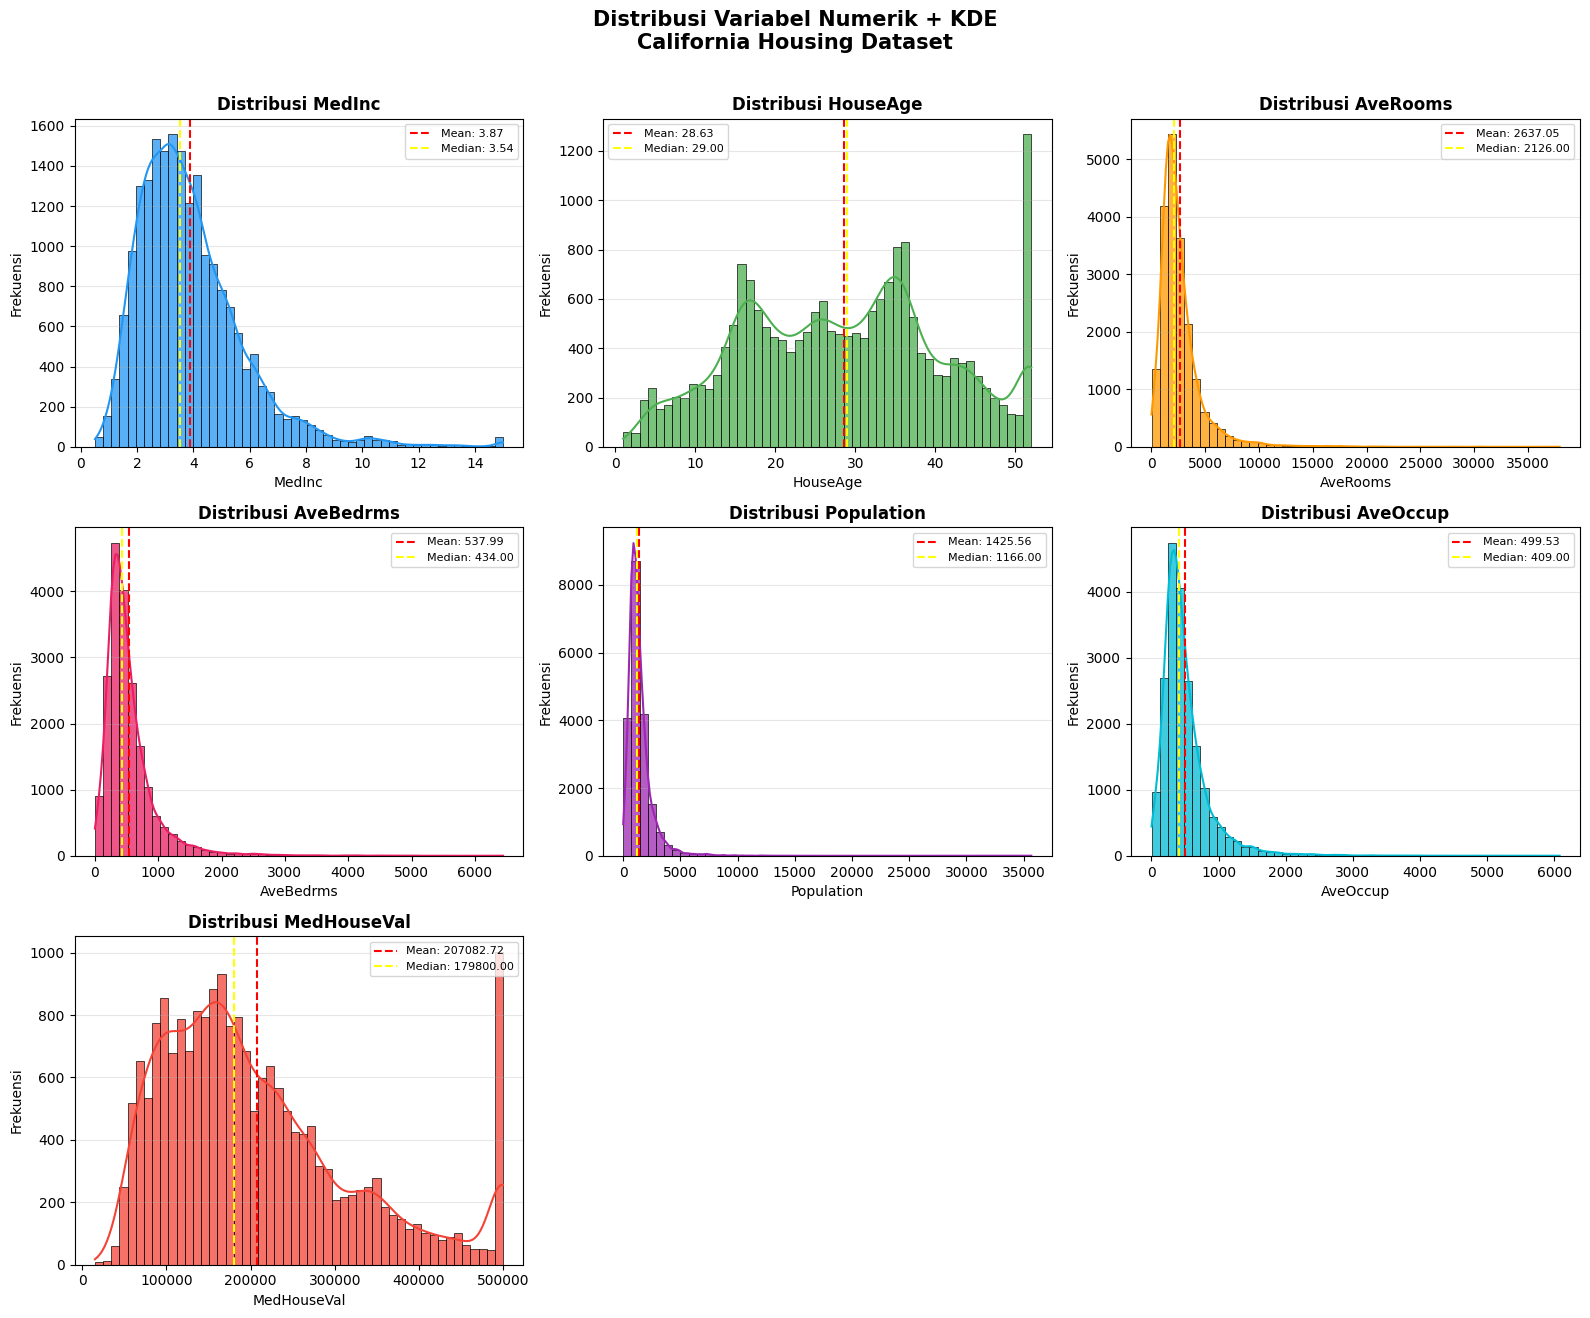

In [23]:
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4', '#F44336']

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=50, color=colors[i], alpha=0.75,
                 kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--',
                    linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='yellow', linestyle='--',
                    linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Variabel Numerik + KDE\nCalifornia Housing Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
print(df.columns.tolist())

['Longitude', 'Latitude', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedInc', 'MedHouseVal']


### Interpretasi Histogram

**MedInc (Pendapatan Median) :**
Distribusi MedInc bersifat right-skewed dengan mayoritas nilai terkonsentrasi di rentang 2–5 (×$10.000), menunjukkan dominasi kelas menengah ke bawah. Terdapat outlier pada nilai ekstrem yang apabila tidak diidentifikasi sejak awal akan membuat visualisasi tampak timpang dan blok lain kehilangan representasinya. Bagi Trevor, segmen menengah ini merepresentasikan target pasar yang paling jelas.

**Population (Jumlah Penduduk) :**
Distribusi Population bersifat right-skewed dengan mayoritas blok berpopulasi kecil hingga menengah. Blok-blok urban dengan populasi ekstrem jumlahnya sedikit namun berpotensi mendistorsi analisis apabila tidak diidentifikasi sejak awal.

**MedHouseVal (Nilai Median Rumah) :**
Distribusi MedHouseVal bersifat right-skewed dengan mayoritas harga rumah berada di segmen menengah ke bawah. Blok dengan harga ekstrem jumlahnya minoritas namun cukup signifikan sebagai outlier yang perlu diwaspadai.

**HouseAge (Usia Rumah) :**
Distribusi HouseAge didominasi rumah berusia tua, mencerminkan bahwa kota-kota besar California sudah lama berkembang dan memiliki lebih banyak blok dibanding kota suburban yang baru.

**AveRooms & AveBedrms :**
Keduanya berdistribusi right-skewed dengan mayoritas di rentang standar. Kedua variabel ini berkorelasi erat rumah dengan ruangan banyak cenderung memiliki kamar tidur lebih banyak, karena keduanya berada dalam satu konteks yang sama.

**AveOccup (Rata-rata Penghuni) :**
Mayoritas blok memiliki rata-rata 2–4 penghuni per rumah. Terdapat outlier ekstrem yang perlu diwaspadai karena kepadatan penghuni yang sangat tinggi dapat membuat hasil analisis menjadi timpang.

---
## SOAL 3: Analisis Korelasi

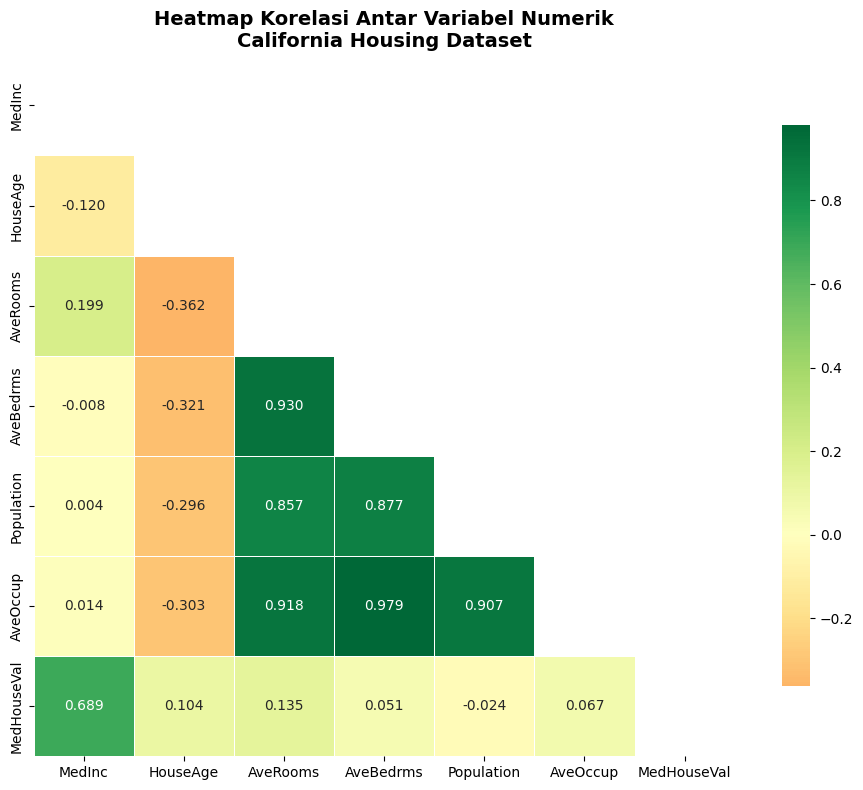

=== Korelasi dengan MedHouseVal ===
MedHouseVal    1.000
MedInc         0.689
AveRooms       0.135
HouseAge       0.104
AveOccup       0.067
AveBedrms      0.051
Population    -0.024
Name: MedHouseVal, dtype: float64

✅ Korelasi TERTINGGI: ('AveOccup', 'AveBedrms') = 0.979
❌ Korelasi TERENDAH : ('AveRooms', 'HouseAge') = -0.362

=== Semua Pasangan Korelasi ===
AveRooms     HouseAge     -0.362
AveBedrms    HouseAge     -0.321
AveOccup     HouseAge     -0.303
Population   HouseAge     -0.296
HouseAge     MedInc       -0.120
MedHouseVal  Population   -0.024
AveBedrms    MedInc       -0.008
Population   MedInc        0.004
AveOccup     MedInc        0.014
MedHouseVal  AveBedrms     0.051
             AveOccup      0.067
             HouseAge      0.104
             AveRooms      0.135
AveRooms     MedInc        0.199
MedHouseVal  MedInc        0.689
Population   AveRooms      0.857
             AveBedrms     0.877
AveOccup     Population    0.907
             AveRooms      0.918
AveBedrms 

In [25]:
corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            mask=mask,
            annot_kws={'size': 10})

plt.title('Heatmap Korelasi Antar Variabel Numerik\nCalifornia Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('soal3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Ambil pasangan unik (segitiga atas saja)
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna().sort_values()

print('=== Korelasi dengan MedHouseVal ===')
print(corr_matrix['MedHouseVal'].sort_values(ascending=False).round(3))
print(f'\n✅ Korelasi TERTINGGI: {corr_pairs.idxmax()} = {corr_pairs.max():.3f}')
print(f'❌ Korelasi TERENDAH : {corr_pairs.idxmin()} = {corr_pairs.min():.3f}')
print('\n=== Semua Pasangan Korelasi ===')
print(corr_pairs.round(3))

### Interpretasi Korelasi

**Korelasi Tertinggi: AveOccup ↔ AveBedrms (0.979)**  
Korelasi tertinggi terjadi antara AveOccup dan AveBedrms, keduanya berada dalam satu konteks yang sama yaitu kapasitas hunian rumah. Rumah dengan kamar tidur lebih banyak secara otomatis cenderung menampung lebih banyak penghuni. Ini bersifat dikotomis namun saling memperkuat, keduanya sama-sama mencerminkan ukuran dan kapasitas fisik rumah.

**Korelasi Terendah: AveRooms ↔ HouseAge (-0.362)**  
Korelasi terendah terjadi antara AveRooms dan HouseAge dengan nilai negatif. Artinya, rumah-rumah tua cenderung memiliki jumlah ruangan lebih sedikit dibanding rumah baru. Hal ini mencerminkan perkembangan standar konstruksi, rumah yang dibangun lebih baru di California cenderung dirancang lebih luas dan memiliki lebih banyak ruangan dibanding rumah lama.

**Korelasi Positif : AveOccup ↔ AveRooms (0.918) & Population ↔ AveBedrms (0.877)**  
Selain korelasi tertinggi, terdapat beberapa pasangan dengan korelasi positif kuat. Ini semua berada dalam satu konteks yang sama, semakin besar kapasitas fisik rumah, semakin banyak penghuni dan populasi di blok tersebut.

**Korelasi Negatif: AveRooms ↔ HouseAge & HouseAge ↔ MedInc**  
Variabel HouseAge konsisten berkorelasi negatif dengan hampir semua variabel lain, rumah tua cenderung lebih kecil, berpendapatan lebih rendah, dan berpopulasi lebih sedikit. Ini mengindikasikan bahwa daerah dengan rumah-rumah tua di California umumnya merupakan kawasan yang pertumbuhannya stagnan dibanding daerah dengan rumah baru yang lebih dinamis.

---
## SOAL 4: Analisis Regresi Berganda

In [26]:
X_cols = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
y_col  = 'MedInc'

X = df[X_cols]
y = df[y_col]

X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     6512.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:14:34   Log-Likelihood:                -30386.
No. Observations:               20000   AIC:                         6.079e+04
Df Residuals:                   19993   BIC:                         6.084e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.5574      0.028     90.608      

In [27]:
X_cols = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
y_col  = 'MedInc'

X = df[X_cols]
y = df[y_col]

X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     6512.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:14:34   Log-Likelihood:                -30386.
No. Observations:               20000   AIC:                         6.079e+04
Df Residuals:                   19993   BIC:                         6.084e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.5574      0.028     90.608      

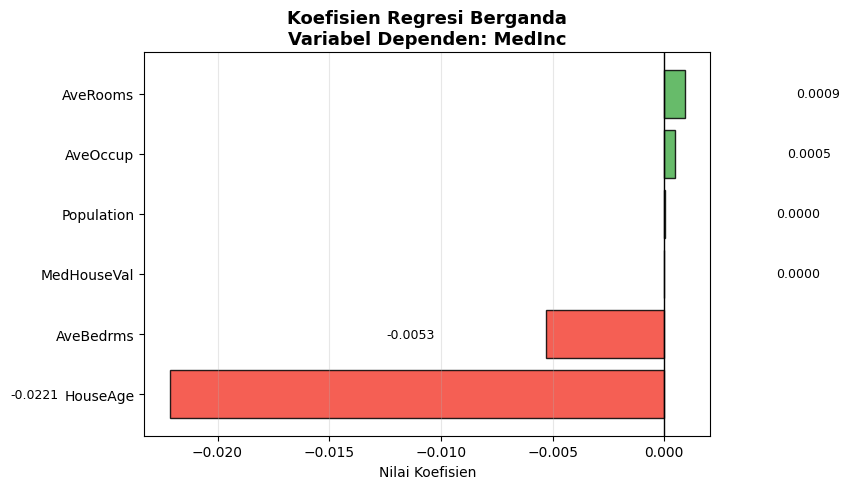


📌 R-squared     : 0.6615
📌 Adj R-squared : 0.6614

📌 Variabel berdasarkan |koefisien| terbesar:
HouseAge       0.0221
AveBedrms      0.0053
AveRooms       0.0009
AveOccup       0.0005
Population     0.0000
MedHouseVal    0.0000
dtype: float64


In [28]:
coef = model.params.drop('const').sort_values()
colors_bar = ['#F44336' if c < 0 else '#4CAF50' for c in coef]

plt.figure(figsize=(9, 5))
bars = plt.barh(coef.index, coef.values, color=colors_bar, alpha=0.85, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Koefisien Regresi Berganda\nVariabel Dependen: MedInc', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien')
for bar, val in zip(bars, coef.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n📌 R-squared     : {model.rsquared:.4f}')
print(f'📌 Adj R-squared : {model.rsquared_adj:.4f}')
print(f'\n📌 Variabel berdasarkan |koefisien| terbesar:')
print(coef.abs().sort_values(ascending=False).round(4))

### Interpretasi Regresi Berganda

**Variabel Paling Berpengaruh :**
MedHouseVal merupakan variabel paling berpengaruh terhadap MedInc harga rumah dan pendapatan bersifat linear secara sebab akibat. Tanpa pendapatan tinggi, penghuni tidak mungkin mampu membeli properti bernilai tinggi. AveRooms turut berkontribusi sebagai indikator pendukung karena rumah dengan ruangan lebih banyak mencerminkan kemampuan daya beli penghuninya.

**Pengaruh Lemah (HouseAge & Population) :**
Kedua variabel ini memiliki koefisien yang nyaris nol di grafik (-0.0138 dan 0.0000). Pengaruh HouseAge menjadi lemah karena efeknya saling cancel out (rumah tua premium dan rumah baru di daerah berkembang sama-sama dihuni warga berpendapatan tinggi). Sementara itu, Population tidak berdampak langsung karena efeknya kondisional, tergantung apakah blok yang padat tersebut produktif secara ekonomi atau sekadar overcrowded dengan daya beli rendah.

**Nilai R-squared :**
Jika nilai R-squared tidak terlalu tinggi, bukan berarti model kekurangan variabel penting. Faktor eksternal (seperti infrastruktur dan keamanan) secara implisit sudah terwakili oleh tingginya MedHouseVal dan MedInc. Keterbatasan performa model ini lebih banyak disebabkan oleh distorsi akibat multicollinearity (seperti pada variabel ruangan dan kamar), bukan karena data yang kurang lengkap.

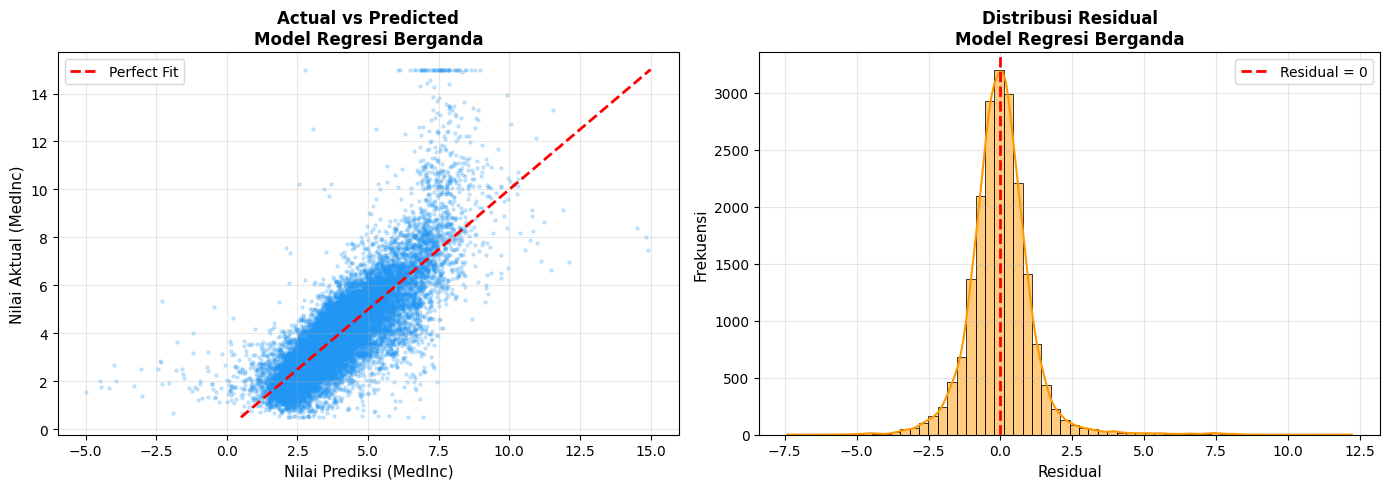

In [29]:
y_pred = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, y, alpha=0.2, color='#2196F3', s=5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()],
             color='red', linewidth=2, linestyle='--', label='Perfect Fit')
axes[0].set_xlabel('Nilai Prediksi (MedInc)', fontsize=11)
axes[0].set_ylabel('Nilai Aktual (MedInc)', fontsize=11)
axes[0].set_title('Actual vs Predicted\nModel Regresi Berganda', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.histplot(residuals, bins=60, kde=True, color='#FF9800', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Residual = 0')
axes[1].set_xlabel('Residual', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].set_title('Distribusi Residual\nModel Regresi Berganda', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## SOAL 5: Analisis Time Series

### 5a. Apakah Time Series Dapat Diterapkan?

California Housing Dataset tidak dapat dianalisis menggunakan Time Series karena tidak memiliki kolom waktu. Dataset ini bersifat cross-sectional dikumpulkan pada satu titik waktu yaitu sensus 1990, sehingga tidak ada urutan temporal yang bisa dianalisis. Namun apabila Trevor mengumpulkan data harga rumah secara berkala misalnya bulanan selama 10 tahun barulah Time Series dapat diterapkan untuk mengidentifikasi tren kenaikan harga dan pola musiman penjualan.

### 5b. Konsep Penting dalam Time Series

**Tren :**
Tren adalah pola jangka panjang yang naik atau turun secara konsisten dalam data. Contoh: harga rumah California yang cenderung naik setiap dekade seiring pertumbuhan ekonomi dan keterbatasan lahan.

**Musiman (Seasonality) :**
Musiman adalah pola yang berulang dalam periode tetap. Contoh: penjualan rumah yang selalu meningkat setiap musim semi dan menurun di musim dingin pola ini berulang setiap tahun secara konsisten.

**Noise :**
Noise adalah fluktuasi acak yang tidak dapat diprediksi dan tidak berulang. Contoh: anjloknya harga rumah akibat krisis finansial 2008 yang terjadi tiba-tiba dan tidak bisa diantisipasi sebelumnya.